# Level-2 Task-2 Time Series Analysis – Stock Price Dataset

# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

sns.set()

# 2. Load Dataset

In [2]:
df = pd.read_csv("C:/Users/dhine/Downloads/2) Stock Prices Data Set (1).csv")

df.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


# 3. Data Understanding

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  object 
 1   date    497472 non-null  object 
 2   open    497461 non-null  float64
 3   high    497464 non-null  float64
 4   low     497464 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 26.6+ MB


,open,high,low,close,volume
count,497461.000000,497464.000000,497464.000000,497472.000000,4.974720e+05
mean,86.352275,87.132562,85.552467,86.369082,4.253611e+06
std,101.471228,102.312062,100.570957,101.472407,8.232139e+06
min,1.620000,1.690000,1.500000,1.590000,0.000000e+00
25%,41.690000,42.090000,41.280000,41.703750,1.080166e+06
50%,64.970000,65.560000,64.353700,64.980000,2.084896e+06
75%,98.410000,99.230000,97.580000,98.420000,4.271928e+06
max,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08


# 4. Convert Date Column

In [4]:
# Replace 'Date' if column name is different
df['date'] = pd.to_datetime(df['date'])

# Set Date as index
df.set_index('date', inplace=True)

# Sort data
df = df.sort_index()

df.head()

,symbol,open,high,low,close,volume
date,,,,,,
2014-01-02,AAL,25.0700,25.8200,25.0600,25.3600,8998943
2014-01-02,AAPL,79.3828,79.5756,78.8601,79.0185,58791957
2014-01-02,AAP,110.3600,111.8800,109.2900,109.7400,542711
2014-01-02,ABBV,52.1200,52.3300,51.5200,51.9800,4569061
2014-01-02,ABC,70.1100,70.2300,69.4800,69.8900,1148391


# 5. Select Target Variable

In [6]:
# Usually 'Close' price is used
ts = df['close']

# 6. Plot Time Series

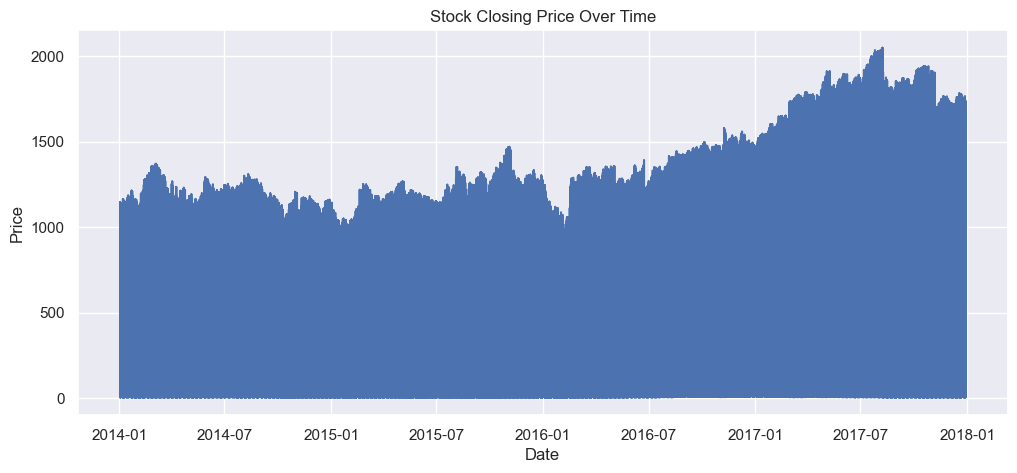

In [7]:
plt.figure(figsize=(12,5))
plt.plot(ts)
plt.title("Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

# 7. Rolling Mean (Trend Analysis)

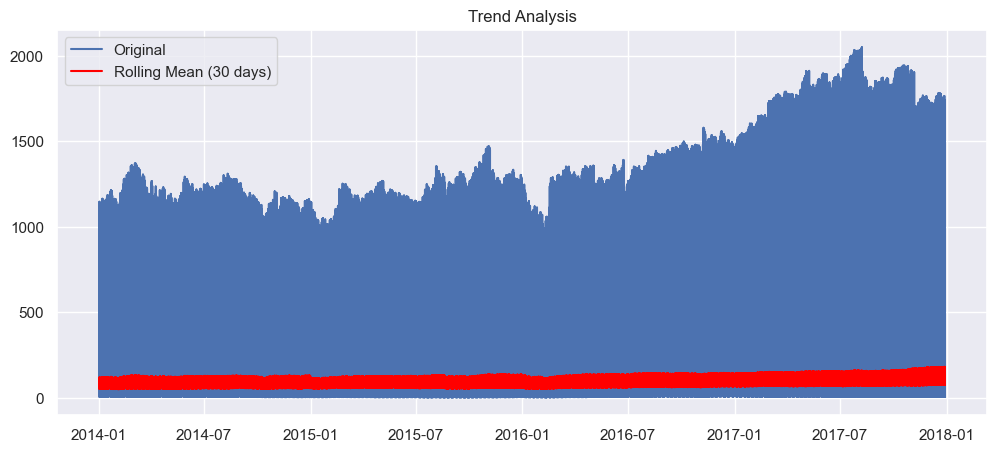

In [8]:
rolling_mean = ts.rolling(window=30).mean()

plt.figure(figsize=(12,5))
plt.plot(ts, label='Original')
plt.plot(rolling_mean, label='Rolling Mean (30 days)', color='red')
plt.legend()
plt.title("Trend Analysis")
plt.show()

# 8. Decomposition (Trend + Seasonality)

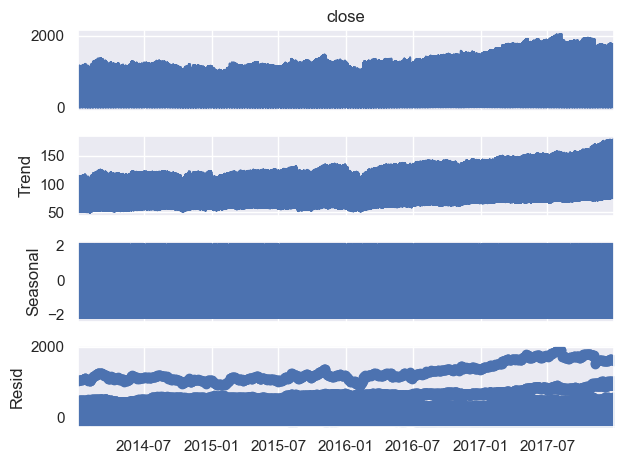

In [9]:
decomposition = seasonal_decompose(ts, model='additive', period=30)

decomposition.plot()
plt.show()

# 9. Make Data Stationary (Differencing)

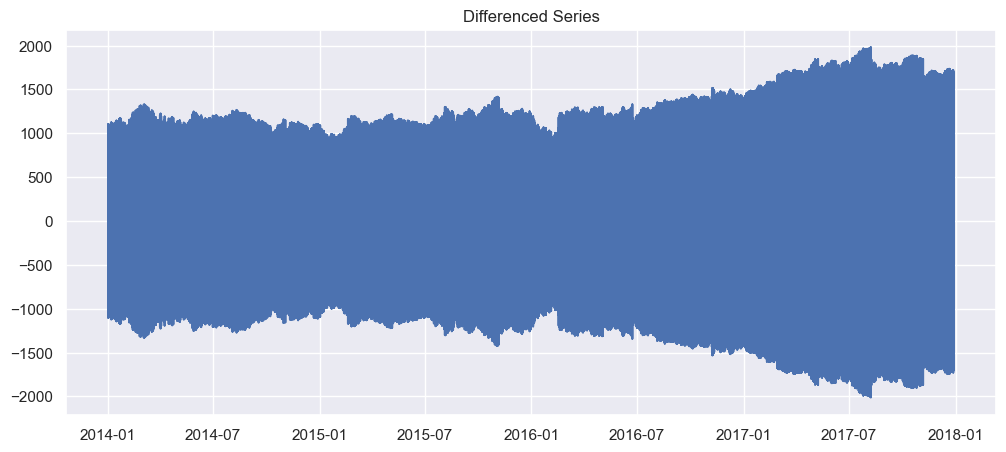

In [11]:
ts_diff = ts.diff().dropna()

plt.figure(figsize=(12,5))
plt.plot(ts_diff)
plt.title("Differenced Series")
plt.show()

## Key Insights

- Stock prices show clear trend over time
- Data is non-stationary (needs differencing)

## Conclusion

- Time series analysis helps predict stock price trends
- Useful for financial decision making